In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time
import subprocess
import random
import csv

#### Directories

In [20]:
ROOT = Path().resolve()
TEST = ROOT / "tests"
RESULTS = ROOT / "results"

RESULTS.mkdir(exist_ok=True)

Benchmark_dir = Path("/home/rummy/work/cvc5test/cvc5/Benchmarking_CRT/QF_NIA")
cvc5_path = Path("/home/rummy/work/cvc5test/cvc5/build/bin/cvc5")
z3_path = Path("/usr/bin/z3")

#### Testing

In [21]:
files_per_folder = 50 # take 50 file from each subfolder of QF_NIA
selected_files = []

for folder in sorted(Benchmark_dir.iterdir()):
    all_files = sorted(folder.rglob("*.smt2"))
    taken = all_files[:files_per_folder]
    selected_files.extend(taken)

In [ ]:
t_cvc5 = ["/home/rummy/work/cvc5test/cvc5/build/bin/cvc5", "--tlimit-per=20000"]
t_crt_ff = ["/home/rummy/work/cvc5test/cvc5/build/bin/cvc5", "--tlimit-per=20000", "--crt-solver=ff"]
t_z3 = ["/usr/bin/z3", "-T:20"]

Timeout = 20

def execute_solver(name, command):
    results = []
    print(f"Executing {name}")
    for i in range(len(selected_files)):
        f = selected_files[i]
        start = time.time()
        try:
            process = subprocess.run(command + [(str(f))], timeout=Timeout, capture_output=True, text=True)
            time_elapsed = time.time() - start
            output = process.stdout.strip().split("\n")[-1]
            if output == "sat":
                result = "SAT"
            elif output == "unsat":
                result = "UNSAT"
            else:
                result = "UNSOLVED"
        except subprocess.TimeoutExpired:
            time_elapsed = Timeout
            result = "UNSOLVED"
        results.append({"File": f.name, "Result": result, "Runtime (s)": round(time_elapsed,4)})
    df = pd.DataFrame(results)
    # Add summary
    sat_count = len(df[df["Result"] == "SAT"])
    unsat_count = len(df[df["Result"] == "UNSAT"])
    unsolved_count = len(df[df["Result"] == "UNSOLVED"])
    time_total = round(df["Runtime (s)"].sum(), 4)
    summary = {"File": "SUMMARY", "Result": f"SAT:{sat_count} UNSAT:{unsat_count} UNSOLVED{unsolved_count}", "Runtime (s)": time_total}

    df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)
    df.to_csv(RESULTS / f"results_{name}.csv", index=False)

execute_solver("cvc5", t_cvc5)
#execute_solver("CRT FF", t_crt_ff)
#execute_solver("Z3", t_z3)

Executing cvc5


In [ ]:
#splitting into easy/hard smt files for cvc5 (anything that took longer than 3 seconds is hard)

cvc5_df = pd.read_csv(RESULTS / "results_cvc5.csv")
cvc5_df = cvc5_df[:-1]
easy_files = [f for f in selected_files if f.name in cvc5_df[cvc5_df["Runtime (s)"] < 3.0]["File"].tolist()]
hard_files = [f for f in selected_files if f.name in cvc5_df[cvc5_df["Runtime (s)"] >= 3.0]["File"].tolist()]
print(f"Easy: {len(easy_files)} , Hard: {len(hard_files)}")

cvc5_df[cvc5_df["File"].isin([f.name for f in easy_files])].to_csv(RESULTS / "results_cvc5_easy.csv", index=False)
cvc5_df[cvc5_df["File"].isin([f.name for f in hard_files])].to_csv(RESULTS / "results_cvc5_hard.csv", index=False)

selected_files = easy_files
execute_solver("CRT FF_easy", t_crt_ff)
execute_solver("Z3_easy", t_z3)

selected_files = hard_files
execute_solver("CRT FF_hard", t_crt_ff)
execute_solver("Z3_hard", t_z3)

In [ ]:
t_crt_ff = ["/home/rummy/work/cvc5test/cvc5/build/bin/cvc5", "--tlimit-per=20000", "--crt-solver=ff"]

easy_df = pd.read_csv(RESULTS / "results_CRT FF_easy.csv")
easy_df = easy_df[:-1]
hard_df = pd.read_csv(RESULTS / "results_CRT FF_hard.csv")
hard_df = hard_df[:-1]
easy_names = easy_df["File"].tolist()
hard_names = hard_df["File"].tolist()
easy_paths = [f for f in easy_files if f.name in easy_names]
hard_paths = [f for f in hard_files if f.name in hard_names]

cvc5_easy: {'File': 'SUMMARY', 'Result': 'SAT:90 UNSAT:109 UNSOLVED:1', 'Runtime (s)': np.float64(92.1558)}
cvc5_hard: {'File': 'SUMMARY', 'Result': 'SAT:13 UNSAT:20 UNSOLVED:302', 'Runtime (s)': np.float64(6292.1091)}


In [36]:
# dropping results with negative runtime
def fix_results(solver):
    df = pd.read_csv(RESULTS / f"results_{solver}.csv")
    df = df[df["Runtime (s)"] > 0]
    return df


def generate_scatter_plot(solver1, solver2, timeout, type=None, subplot=False):
    # axis time taken by cvc5 normally and the other axis time taken by another solver
    # different kind of point for sat and unsat and plot a line y=x
    if not subplot:
        plt.figure(figsize=(8, 8))

    df1 = fix_results(solver1)
    df2 = fix_results(solver2)
    df1 = df1[:-1]  # Drop last row (summary data)
    df2 = df2[:-1]  

    merged = df1.merge(df2, on="File", suffixes=(f"_{1}", f"_{2}"))

    if type == "SAT":
        data = merged[merged["Result_1"] ==  "SAT"]
        title = f"Scatter Plot for SAT only: {solver1} vs {solver2}"
    elif type == "UNSAT":
        data = merged[merged["Result_1"] ==  "UNSAT"]
        title = f"Scatter Plot for UNSAT only: {solver1} vs {solver2} "
    else:
        data = merged
        title = f"Scatter Plot SAT and UNSAT: {solver1} vs {solver2}"

    sat = data[data["Result_1"] == "SAT"]
    unsat = data[data["Result_1"] == "UNSAT"]

    plt.scatter(sat["Runtime (s)_1"], sat["Runtime (s)_2"], marker ="o", label="SAT")
    plt.scatter(unsat["Runtime (s)_1"], unsat["Runtime (s)_2"], marker ="x", label="UNSAT")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(0.01, Timeout)
    plt.ylim(0.01, Timeout)
    plt.xticks([0.01, 0.1, 1, 10], ["0.01", "0.1", "1", "10"])
    plt.yticks([0.01, 0.1, 1, 10], ["0.01", "0.1", "1", "10"])
    
    plt.plot([0.001, timeout], [0.001, timeout], "r--", label="equal") # y = x line
    plt.xlabel(f"{solver1} time (s)")
    plt.ylabel(f"{solver2} time (s)")
    plt.title(title)
    plt.legend()
    if not subplot:
        plt.tight_layout()
        plt.show()


def generate_cactus_plot(solvers, memory, timeout, type=None, subplot=False):
    # Set size and layout
    if not subplot:
        plt.figure(figsize=(10, 6))
    plt.grid(True)

    # Set title and labels
    plt.title(f"Speed of SMT Solvers with Non-Linear Integer Equations ({memory}GB, {timeout}s)")
    plt.ylabel("Runtime (seconds)")

    if type == "SAT":
        for name in solvers:
            plt.xlabel("Problems solved SAT (count)")
            update_cactus_plot(name,"SAT")
            
    elif type == "UNSAT":
        for name in solvers:
            plt.xlabel("Problems solved UNSAT (count)")
            update_cactus_plot(name,"UNSAT")
    else:
        for name in solvers:
            plt.xlabel("Problems solved (count)")
            update_cactus_plot(name)

    # Save and display final cactus plot
    plt.legend()
    if not subplot:
        plt.tight_layout()
        plt.show()

def update_cactus_plot(solver_name, type=None):
    # Populate pandas dataframe with results stored in csv file
    file_name = RESULTS / f"results_{solver_name}.csv" # header row is automatically handled by pandas
    df = pd.read_csv(file_name)
    df = fix_results(solver_name)
    
    # Drop last row from results.csv (contains summary data)
    df = df[:-1]

    if len(df) == 0:
        print(f"No data available for {solver_name}. Skipping plot.")
        return

    ''' #Keep only equations that were successfully solved
    #df["Result"] = df["Result"].apply(ast.literal_eval) # parse result column from string to list object
    #df = df[~df["Result"].apply(lambda x: isinstance(x, list) and "UNKNOWN" in str(x[0][0]))] # ~ means NOT '''

    if type == "SAT":
        df = df[df["Result"].isin(["SAT"])]
    elif type == "UNSAT":
        df = df[df["Result"].isin(["UNSAT"])]
    else:
        df = df[df["Result"].isin(["UNSAT","SAT"])]

    # Sort equations by ascending runtime
    df["Runtime (s)"] = df["Runtime (s)"].astype(float)
    df = df.sort_values(by="Runtime (s)").reset_index(drop=True) # drop original index row

    # Accumulate individual runtimes
    cumulative_runtimes = df["Runtime (s)"].cumsum()
    problem_indices = list(range(1, len(cumulative_runtimes) + 1))

    # Plot number of problems solved against cumulative runtime
    if solver_name.startswith("CRT FF"):
        plt.plot(problem_indices, cumulative_runtimes,
            marker="+", linestyle="-", color="tab:blue", label=solver_name)
    elif solver_name.startswith("cvc5"):
        plt.plot(problem_indices, cumulative_runtimes,
            marker="x", linestyle="-", color="tab:green", label=solver_name)
    elif solver_name.startswith("Z3"):
        plt.plot(problem_indices, cumulative_runtimes,
            marker="^", linestyle="-", color="tab:orange", label=solver_name)
    

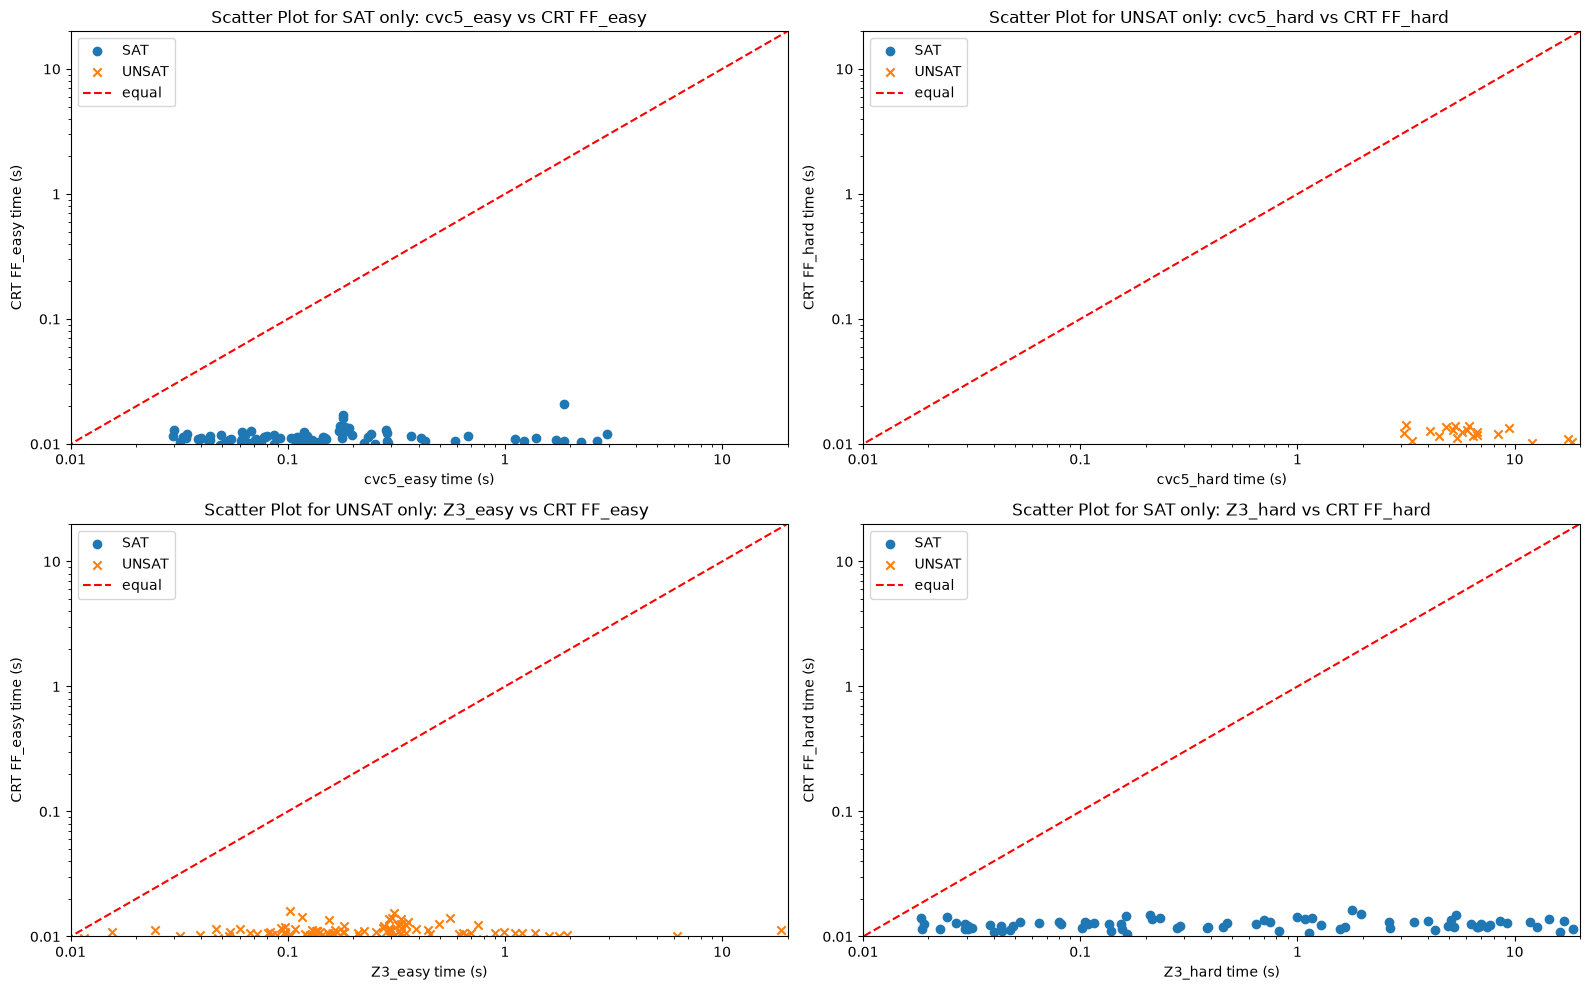

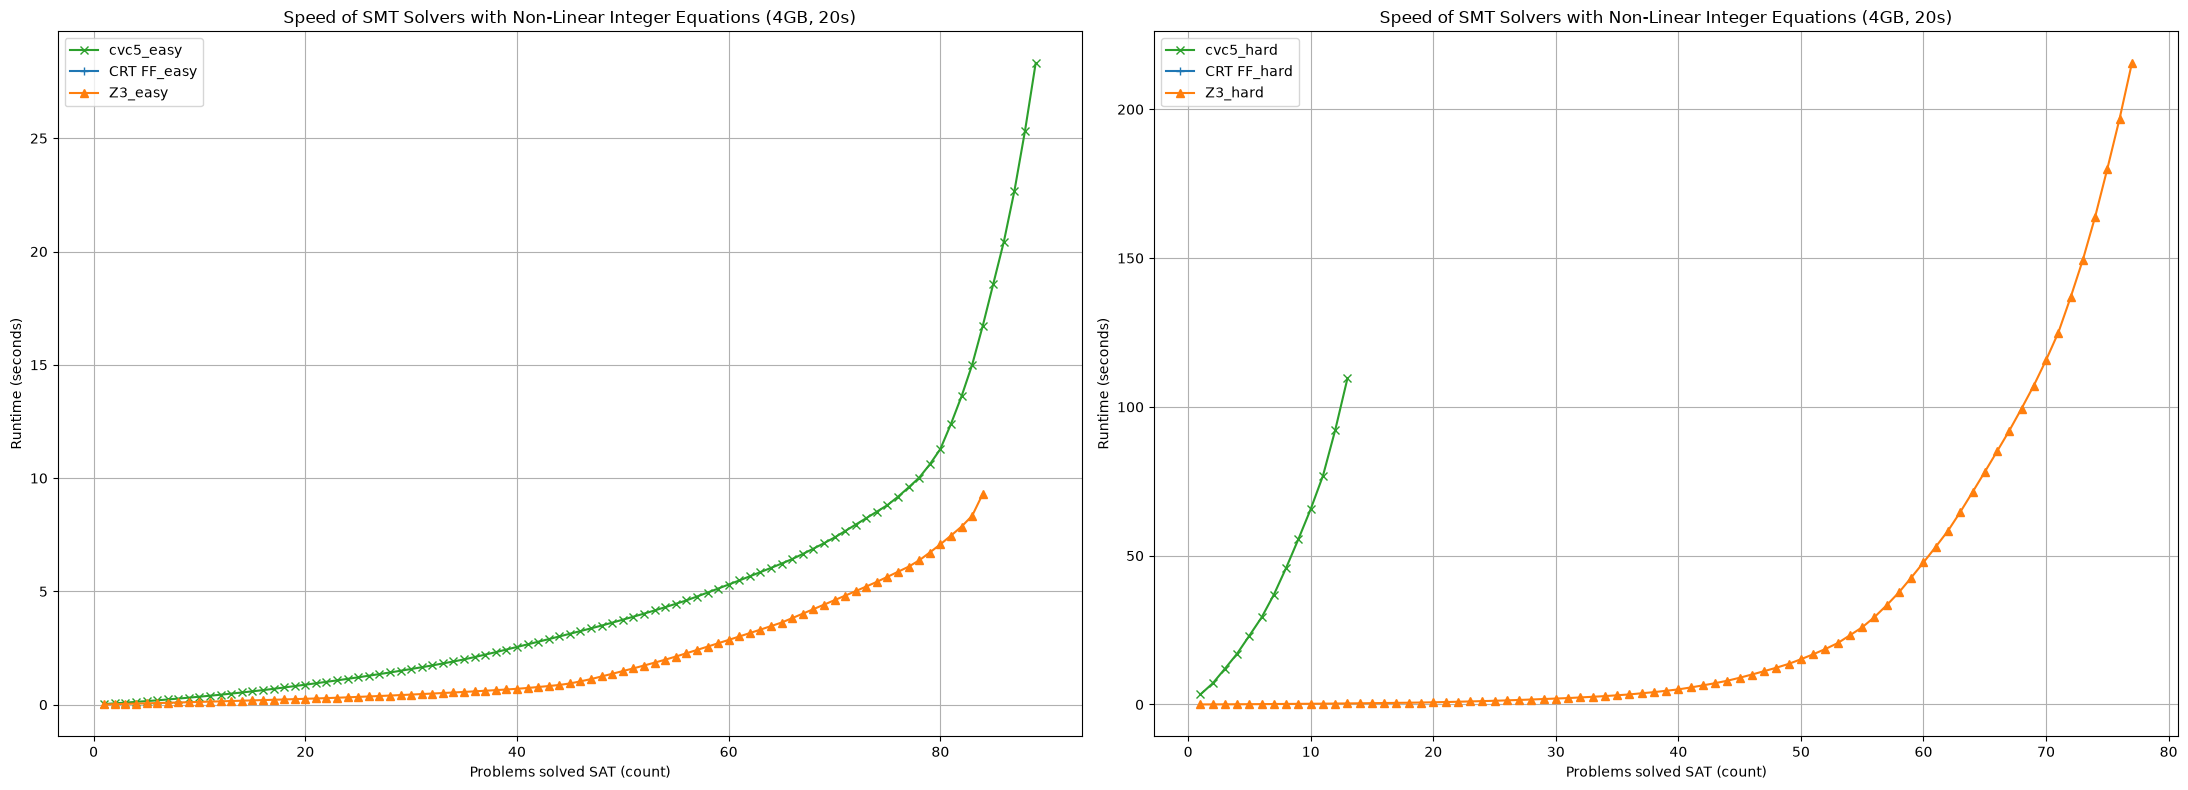

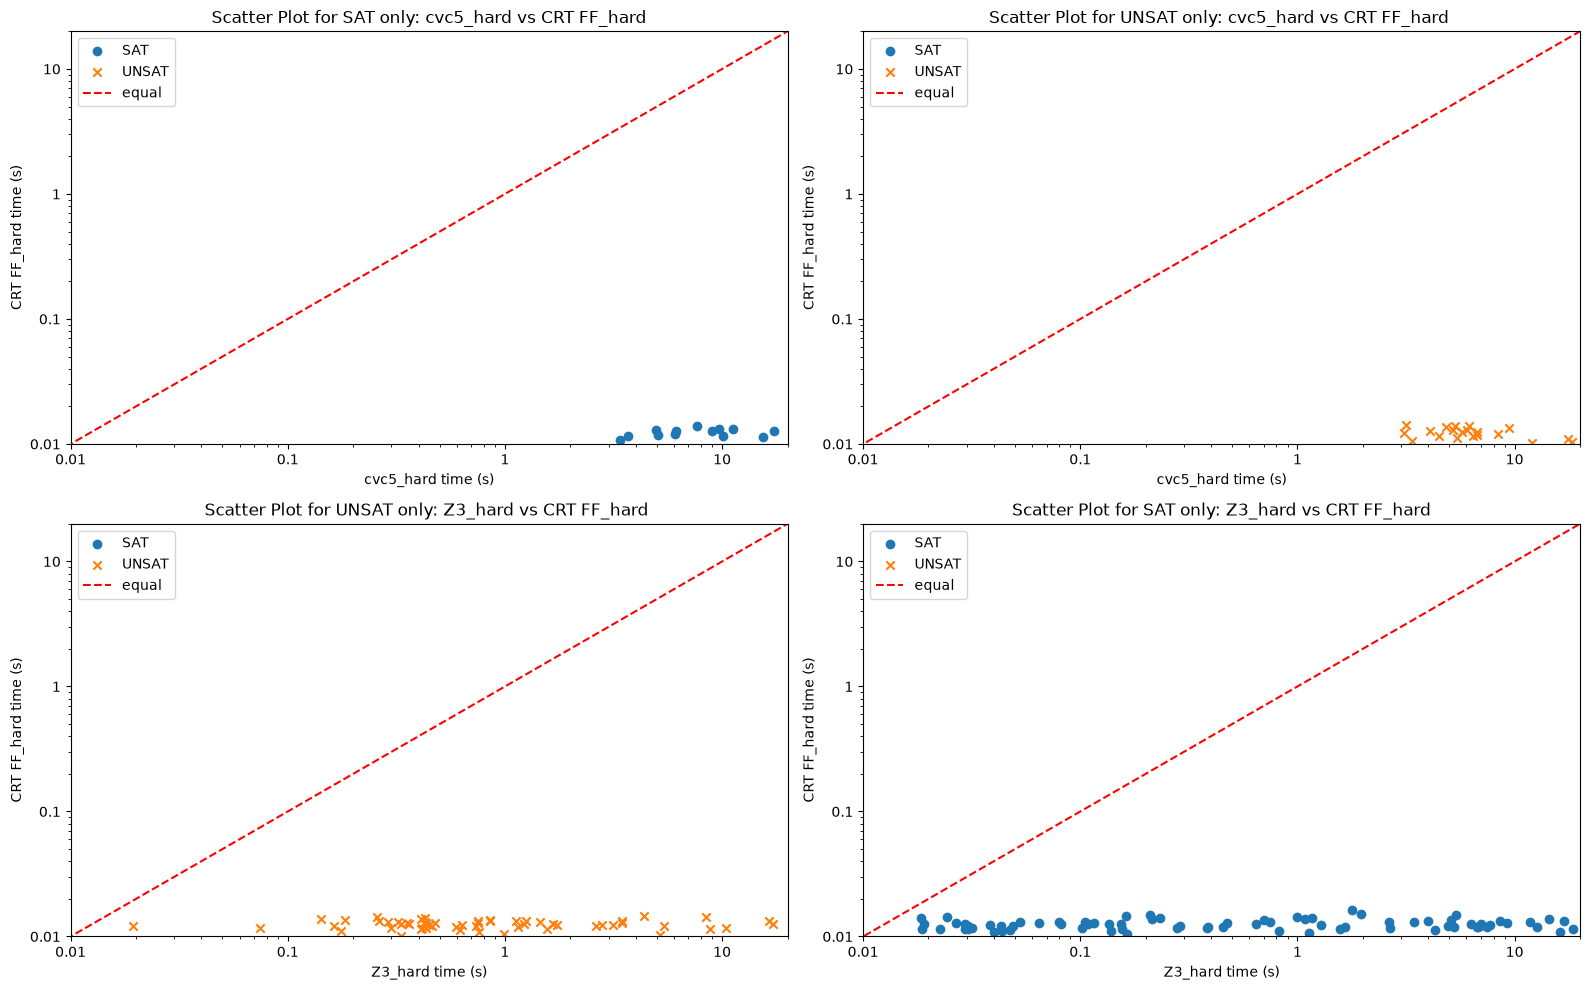

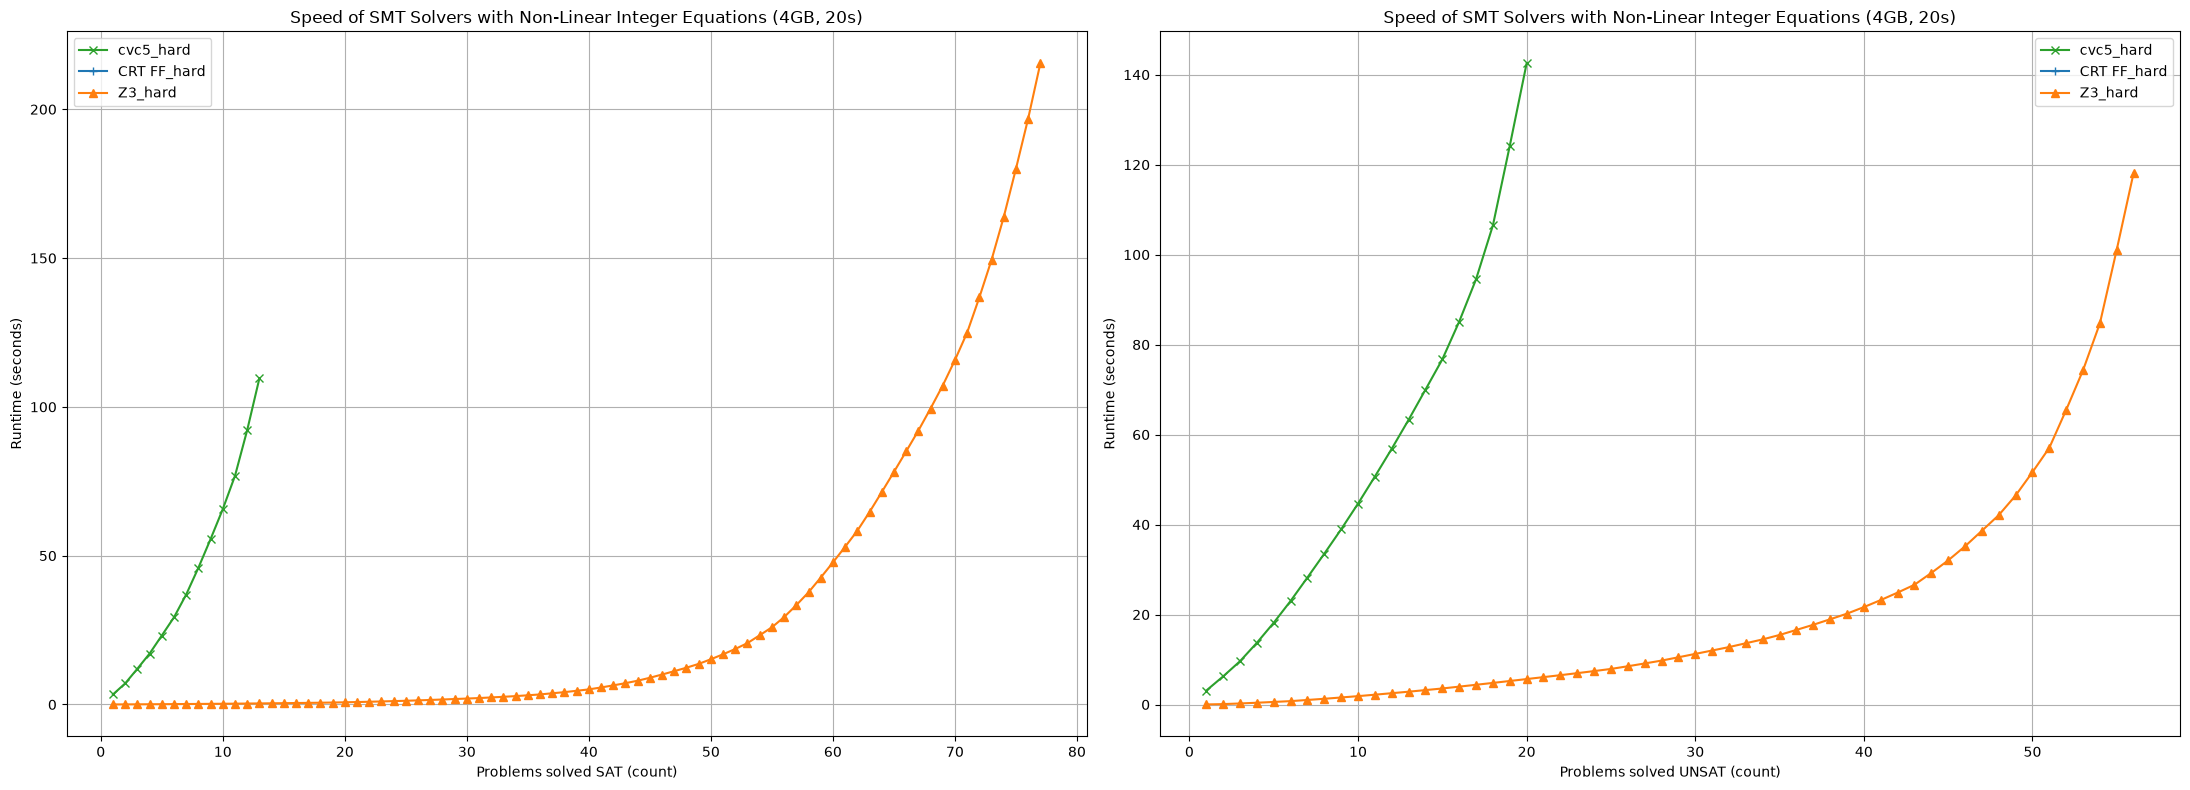

In [38]:
Timeout = 20
'''generate_scatter_plot("cvc5", "CRT FF", Timeout,"SAT")
generate_scatter_plot("cvc5", "CRT FF", Timeout,"UNSAT")
generate_scatter_plot("Z3", "CRT FF", Timeout, "UNSAT")
generate_scatter_plot("Z3", "CRT FF", Timeout, "SAT")


generate_cactus_plot(["cvc5","CRT FF", "Z3"], Timeout, "SAT")
generate_cactus_plot(["cvc5","CRT FF", "Z3"], Timeout, "UNSAT")

#easy files
generate_scatter_plot("cvc5_easy", "CRT FF_easy", Timeout,"SAT")
generate_scatter_plot("cvc5_easy", "CRT FF_easy", Timeout,"UNSAT")
generate_cactus_plot(["cvc5_easy","CRT FF_easy", "Z3_easy"], Timeout, "SAT")
generate_cactus_plot(["cvc5_easy","CRT FF_easy", "Z3_easy"], Timeout, "UNSAT")

#hard files
generate_scatter_plot("cvc5_hard", "CRT FF_hard", Timeout,"SAT")
generate_scatter_plot("cvc5_hard", "CRT FF_hard", Timeout,"UNSAT")
generate_cactus_plot(["cvc5_hard","CRT FF_hard", "Z3_hard"], Timeout, "SAT")
generate_cactus_plot(["cvc5_hard","CRT FF_hard", "Z3_hard"], Timeout, "UNSAT")
'''


#easy files scatter
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
generate_scatter_plot("cvc5_easy", "CRT FF_easy", Timeout,"SAT",True)
plt.subplot(2,2,2)
generate_scatter_plot("cvc5_hard", "CRT FF_hard", Timeout,"UNSAT",True)
plt.subplot(2,2,3)
generate_scatter_plot("Z3_easy", "CRT FF_easy", Timeout, "UNSAT",True)
plt.subplot(2,2,4)
generate_scatter_plot("Z3_hard", "CRT FF_hard", Timeout, "SAT",True)
plt.tight_layout()
plt.show()
#easy files cactus
plt.figure(figsize=(22,8))
plt.subplot(1,2,1)
generate_cactus_plot(["cvc5_easy","CRT FF_easy", "Z3_easy"], 4, Timeout, "SAT", True)
plt.subplot(1,2,2)
generate_cactus_plot(["cvc5_hard","CRT FF_hard", "Z3_hard"], 4, Timeout, "SAT", True)
plt.tight_layout()
plt.show()

#hard files scatter
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
generate_scatter_plot("cvc5_hard", "CRT FF_hard", Timeout,"SAT",True)
plt.subplot(2,2,2)
generate_scatter_plot("cvc5_hard", "CRT FF_hard", Timeout,"UNSAT",True)
plt.subplot(2,2,3)
generate_scatter_plot("Z3_hard", "CRT FF_hard", Timeout, "UNSAT",True)
plt.subplot(2,2,4)  
generate_scatter_plot("Z3_hard", "CRT FF_hard", Timeout, "SAT",True)
plt.tight_layout()
plt.show()
#hard files cactus
plt.figure(figsize=(22,8))
plt.subplot(1,2,1)
generate_cactus_plot(["cvc5_hard","CRT FF_hard", "Z3_hard"], 4, Timeout, "SAT", True)
plt.subplot(1,2,2)
generate_cactus_plot(["cvc5_hard","CRT FF_hard", "Z3_hard"], 4, Timeout, "UNSAT", True)
plt.tight_layout()
plt.show()